LANGKAH 6.5.1: RUL Target Engineering

  SETUP KONFIRMASI — FASE 6B RUL ENGINEERING

  SRC_PATH           : C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\src
  GLOBAL_SEED        : 42
  RUL_UNIT (config)  : days
  INPUT_PATH         : df_ssbs.parquet

  Shape df           : (20423, 76)
  timestamp min      : 2025-07-01 00:00:00
  timestamp max      : 2025-12-14 21:00:00

  Distribusi label   :
    0 (HEALTHY ) :  17,787  (87.09%)
    1 (WARNING ) :   1,247  (6.11%)
    2 (CRITICAL) :   1,389  (6.80%)

  BAGIAN 1 — RUL CALCULATION PER BARIS

  Menghitung RUL... (vektorized per mesin)

  [OK] Kolom 'rul_days' berhasil dibuat.
  Shape df sekarang : (20423, 77)

  BAGIAN 2 — VALIDASI & STATISTIK RUL

-----------------------------------------------------------------
  [A] STATISTIK DESKRIPTIF rul_days
-----------------------------------------------------------------

  min    : 0.04 hari
  max    : 146.92 hari
  mean   : 29.38 hari
  median : 18.88 hari
  std    : 31.5

C:\Users\achma\AppData\Local\Temp\ipykernel_11940\517423743.py:314: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


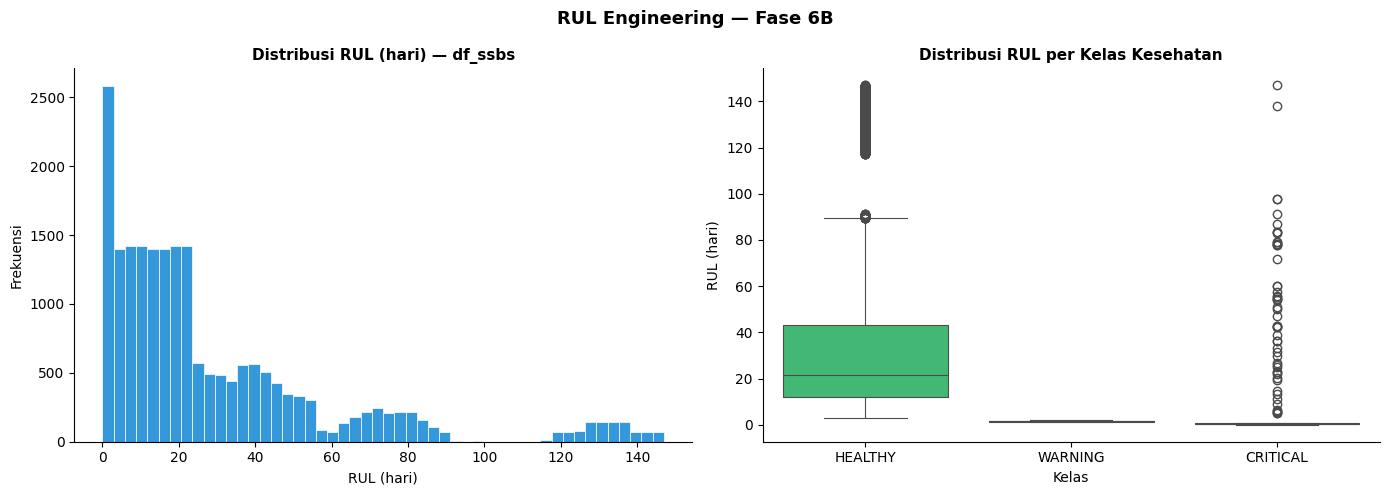


  BAGIAN 4 — EXPORT df_ssbs_rul

-----------------------------------------------------------------
  [FORMAT 1] Parquet — Pipeline Resmi
-----------------------------------------------------------------

  Path        : C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\data\processed\df_ssbs_rul.parquet
  Shape       : (20423, 77)
  Ukuran      : 4.50 MB
  rul_days ada: True

-----------------------------------------------------------------
  [FORMAT 2] CSV — Preview Manual
-----------------------------------------------------------------

  Path        : C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\data\processed\df_ssbs_rul_preview.csv
  Shape       : (20423, 77)
  Ukuran      : 28.05 MB

-----------------------------------------------------------------
  CATATAN
-----------------------------------------------------------------

  df_ssbs_rul.parquet adalah input re

In [1]:
# ============================================================
# FASE 6B — RUL ENGINEERING
# Cell 1: Setup + RUL Calculation + Validasi + Visualisasi + Export
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ----------------------------------------------------------
# [1] SYS.PATH SETUP
# Notebook: notebooks/fase_6_imbalance/
# ML_ROOT  = dua level ke atas
# ----------------------------------------------------------
NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# ----------------------------------------------------------
# [2] IMPORT CONFIG
# ----------------------------------------------------------
from config import DATA_PROCESSED_DIR, GLOBAL_SEED, RUL_UNIT, LABEL_MAP

np.random.seed(GLOBAL_SEED)

# ----------------------------------------------------------
# [3] LOAD DATA
# ----------------------------------------------------------
INPUT_PATH = DATA_PROCESSED_DIR / "df_ssbs.parquet"

df = pd.read_parquet(INPUT_PATH)

df = (
    df
    .sort_values(["machine_id", "timestamp"], ascending=True)
    .reset_index(drop=True)
)

LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}

# ----------------------------------------------------------
# [4] KONFIRMASI SETUP
# ----------------------------------------------------------
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  SETUP KONFIRMASI — FASE 6B RUL ENGINEERING")
print(SEP)
print(f"\n  SRC_PATH           : {SRC_PATH}")
print(f"  GLOBAL_SEED        : {GLOBAL_SEED}")
print(f"  RUL_UNIT (config)  : {RUL_UNIT}")
print(f"  INPUT_PATH         : {INPUT_PATH.name}")
print(f"\n  Shape df           : {df.shape}")
print(f"  timestamp min      : {df['timestamp'].min()}")
print(f"  timestamp max      : {df['timestamp'].max()}")

dist = df["health_label_encoded"].value_counts().sort_index()
print(f"\n  Distribusi label   :")
for code, cnt in dist.items():
    label = LABEL_MAP_INV.get(int(code), "?")
    pct   = cnt / len(df) * 100
    print(f"    {code} ({label:<8}) : {cnt:>7,}  ({pct:.2f}%)")
print(SEP)

# ════════════════════════════════════════════════════════════
# BAGIAN 1 — RUL CALCULATION PER BARIS
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 1 — RUL CALCULATION PER BARIS")
print(SEP)

def calculate_rul(df: pd.DataFrame) -> pd.Series:
    """
    Hitung Remaining Useful Life (RUL) dalam hari per baris.

    Logika per mesin:
    - Cari T_failure_next = failure timestamp pertama
      yang lebih besar dari timestamp baris tersebut.
    - Jika tidak ada failure berikutnya:
      rul_days = max_rul_days mesin tersebut
      (proxy: baris jauh sebelum failure).
    - Jika mesin tidak pernah failure sama sekali:
      max_rul_days = rentang waktu keseluruhan mesin.
    """
    rul_series = pd.Series(index=df.index, dtype=float)

    for machine_id, df_machine in df.groupby("machine_id"):
        df_machine = df_machine.sort_values("timestamp")

        # Semua failure timestamp untuk mesin ini
        failure_timestamps = (
            df_machine[df_machine["failure"] == 1]["timestamp"]
            .sort_values()
            .tolist()
        )

        rul_values = []

        for _, row in df_machine.iterrows():
            ts = row["timestamp"]

            # Cari failure timestamp pertama SETELAH timestamp baris ini
            t_next = next(
                (t for t in failure_timestamps if t > ts),
                None
            )

            if t_next is not None:
                rul_hours = (t_next - ts).total_seconds() / 3600
                rul_days  = round(rul_hours / 24, 2)
            else:
                rul_days = -1  # penanda sementara

            rul_values.append((df_machine.index[
                df_machine.index.get_loc(df_machine[df_machine["timestamp"] == ts].index[0])
                if ts in df_machine["timestamp"].values else 0
            ], rul_days))

        # Bangun Series untuk mesin ini
        rul_machine = pd.Series(
            [v[1] for v in rul_values],
            index=df_machine.index,
            dtype=float,
        )

        # Hitung max_rul_days sebagai pengganti -1
        valid_ruls = rul_machine[rul_machine >= 0]
        if valid_ruls.empty:
            # Mesin tidak pernah failure → rentang waktu keseluruhan
            t_min = df_machine["timestamp"].min()
            t_max = df_machine["timestamp"].max()
            max_rul_days = round(
                (t_max - t_min).total_seconds() / 3600 / 24, 2
            )
        else:
            max_rul_days = valid_ruls.max()

        # Ganti semua -1 dengan max_rul_days
        rul_machine[rul_machine < 0] = max_rul_days
        rul_machine = rul_machine.round(2)

        rul_series[df_machine.index] = rul_machine

    return rul_series


# --- Versi vektorized yang lebih cepat ---
def calculate_rul_fast(df: pd.DataFrame) -> pd.Series:
    """
    Implementasi vektorized untuk menghitung RUL per baris.
    Lebih cepat dari iterasi baris-per-baris.
    """
    rul_all = []

    for machine_id, df_m in df.groupby("machine_id"):
        df_m      = df_m.sort_values("timestamp").copy()
        idx       = df_m.index
        ts_arr    = df_m["timestamp"].values
        fail_arr  = df_m["failure"].values

        fail_times = df_m.loc[df_m["failure"] == 1, "timestamp"].values

        rul_days_arr = np.full(len(df_m), -1.0)

        for i, ts in enumerate(ts_arr):
            future_fails = fail_times[fail_times > ts]
            if len(future_fails) > 0:
                t_next      = future_fails.min()
                delta_hrs   = (t_next - ts) / np.timedelta64(1, "h")
                rul_days_arr[i] = round(delta_hrs / 24, 2)

        # max_rul_days pengganti -1
        valid = rul_days_arr[rul_days_arr >= 0]
        if len(valid) == 0:
            t_min = ts_arr.min()
            t_max = ts_arr.max()
            max_rul = round(
                (t_max - t_min) / np.timedelta64(1, "h") / 24, 2
            )
        else:
            max_rul = valid.max()

        rul_days_arr[rul_days_arr < 0] = max_rul
        rul_days_arr = np.round(rul_days_arr, 2)

        rul_all.append(pd.Series(rul_days_arr, index=idx))

    return pd.concat(rul_all)


print("\n  Menghitung RUL... (vektorized per mesin)")
df["rul_days"] = calculate_rul_fast(df)

# Re-sort setelah kalkulasi (groupby bisa acak urutan)
df = df.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)

print(f"\n  [OK] Kolom 'rul_days' berhasil dibuat.")
print(f"  Shape df sekarang : {df.shape}")

# ════════════════════════════════════════════════════════════
# BAGIAN 2 — VALIDASI & STATISTIK RUL
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 2 — VALIDASI & STATISTIK RUL")
print(SEP)

# [1] Statistik deskriptif
print(f"\n{sep}")
print("  [A] STATISTIK DESKRIPTIF rul_days")
print(sep)
print(f"\n  min    : {df['rul_days'].min():.2f} hari")
print(f"  max    : {df['rul_days'].max():.2f} hari")
print(f"  mean   : {df['rul_days'].mean():.2f} hari")
print(f"  median : {df['rul_days'].median():.2f} hari")
print(f"  std    : {df['rul_days'].std():.2f} hari")

# [2] Distribusi RUL per kelas
print(f"\n{sep}")
print("  [B] DISTRIBUSI RUL PER KELAS (ekspektasi: CRITICAL < WARNING < HEALTHY)")
print(sep)
print()

rul_per_class = (
    df.groupby("health_label_encoded")["rul_days"]
    .agg(mean_rul="mean", min_rul="min", max_rul="max")
    .round(2)
    .reset_index()
)

print(f"  {'Label':<12} {'Code':>5}  {'mean_rul':>10}  {'min_rul':>10}  {'max_rul':>10}")
print(f"  {'-'*55}")
for _, row in rul_per_class.iterrows():
    code  = int(row["health_label_encoded"])
    label = LABEL_MAP_INV.get(code, "?")
    print(f"  {label:<12} {code:>5}  {row['mean_rul']:>10.2f}  "
          f"{row['min_rul']:>10.2f}  {row['max_rul']:>10.2f}")

# Cek ekspektasi logis
mean_rul_map = {
    int(r["health_label_encoded"]): r["mean_rul"]
    for _, r in rul_per_class.iterrows()
}
c_mean = mean_rul_map.get(LABEL_MAP["CRITICAL"], 0)
w_mean = mean_rul_map.get(LABEL_MAP["WARNING"],  0)
h_mean = mean_rul_map.get(LABEL_MAP["HEALTHY"],  0)

print(f"\n  Urutan mean RUL  : CRITICAL={c_mean:.2f} < WARNING={w_mean:.2f} < HEALTHY={h_mean:.2f}")
logic_ok = (c_mean < w_mean < h_mean)
print(f"  Ekspektasi logis : {'[OK] ✅ Terpenuhi' if logic_ok else '[WARN] ❌ Tidak sesuai'}")

# [3] Cek NaN dan nilai negatif
print(f"\n{sep}")
print("  [C] CEK NaN DAN NILAI NEGATIF")
print(sep)
n_nan = int(df["rul_days"].isna().sum())
n_neg = int((df["rul_days"] < 0).sum())
print(f"\n  NaN di rul_days      : {n_nan}  → {'[OK]' if n_nan == 0 else '[WARN]'}")
print(f"  Nilai < 0 di rul_days: {n_neg}  → {'[OK]' if n_neg == 0 else '[WARN]'}")

# [4] 5 contoh per kelas
print(f"\n{sep}")
print("  [D] 5 CONTOH BARIS PER KELAS")
print(sep)

PREVIEW_COLS = [
    "timestamp", "machine_id", "health_label_confirmed",
    "rul_days", "failure"
]
preview_cols_ok = [c for c in PREVIEW_COLS if c in df.columns]

for code in sorted(LABEL_MAP_INV.keys()):
    label = LABEL_MAP_INV[code]
    subset = df[df["health_label_encoded"] == code]
    print(f"\n  --- {label} ({len(subset):,} baris) ---")
    print(subset[preview_cols_ok].head(5).to_string(index=False))

# ════════════════════════════════════════════════════════════
# BAGIAN 3 — VISUALISASI
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 3 — VISUALISASI RUL")
print(SEP)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RUL Engineering — Fase 6B",
             fontsize=13, fontweight="bold")

# Subplot 1: Histogram distribusi RUL
axes[0].hist(df["rul_days"], bins=50, color="#3498db",
             edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribusi RUL (hari) — df_ssbs", fontsize=11,
                  fontweight="bold")
axes[0].set_xlabel("RUL (hari)", fontsize=10)
axes[0].set_ylabel("Frekuensi", fontsize=10)
axes[0].spines[["top", "right"]].set_visible(False)

# Subplot 2: Boxplot RUL per kelas
box_order   = ["HEALTHY", "WARNING", "CRITICAL"]
box_palette = {"HEALTHY": "#2ecc71", "WARNING": "#f39c12",
               "CRITICAL": "#e74c3c"}

# Pastikan kolom health_label_confirmed tersedia
if "health_label_confirmed" in df.columns:
    sns.boxplot(
        data    = df,
        x       = "health_label_confirmed",
        y       = "rul_days",
        order   = [o for o in box_order if o in df["health_label_confirmed"].unique()],
        palette = box_palette,
        ax      = axes[1],
        linewidth = 0.8,
    )
else:
    axes[1].text(0.5, 0.5, "health_label_confirmed\ntidak tersedia",
                 ha="center", va="center", transform=axes[1].transAxes)

axes[1].set_title("Distribusi RUL per Kelas Kesehatan", fontsize=11,
                  fontweight="bold")
axes[1].set_xlabel("Kelas", fontsize=10)
axes[1].set_ylabel("RUL (hari)", fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
# BAGIAN 4 — EXPORT
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 4 — EXPORT df_ssbs_rul")
print(SEP)

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PARQUET_PATH = DATA_PROCESSED_DIR / "df_ssbs_rul.parquet"
CSV_PATH     = DATA_PROCESSED_DIR / "df_ssbs_rul_preview.csv"

# Export Parquet
df.to_parquet(PARQUET_PATH, index=False)
parquet_mb = PARQUET_PATH.stat().st_size / (1024 ** 2)

# Export CSV
df.to_csv(CSV_PATH, index=False)
csv_mb = CSV_PATH.stat().st_size / (1024 ** 2)

print(f"\n{sep}")
print("  [FORMAT 1] Parquet — Pipeline Resmi")
print(sep)
print(f"\n  Path        : {PARQUET_PATH}")
print(f"  Shape       : {df.shape}")
print(f"  Ukuran      : {parquet_mb:.2f} MB")
print(f"  rul_days ada: {'rul_days' in df.columns}")

print(f"\n{sep}")
print("  [FORMAT 2] CSV — Preview Manual")
print(sep)
print(f"\n  Path        : {CSV_PATH}")
print(f"  Shape       : {df.shape}")
print(f"  Ukuran      : {csv_mb:.2f} MB")

print(f"\n{sep}")
print("  CATATAN")
print(sep)
print("\n  df_ssbs_rul.parquet adalah input resmi Fase 7")
print("  (Time-Aware Split & SMOTE on X_train).")

print(f"\n{SEP}")
print("  [OK] RUL Engineering Fase 6B SELESAI.")
print(f"  [OK] Output : df_ssbs_rul.parquet  "
      f"({df.shape[0]:,} baris × {df.shape[1]} kolom)")
print(f"  [OK] Kolom baru : rul_days (dalam {RUL_UNIT})")
print(SEP)
